In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error

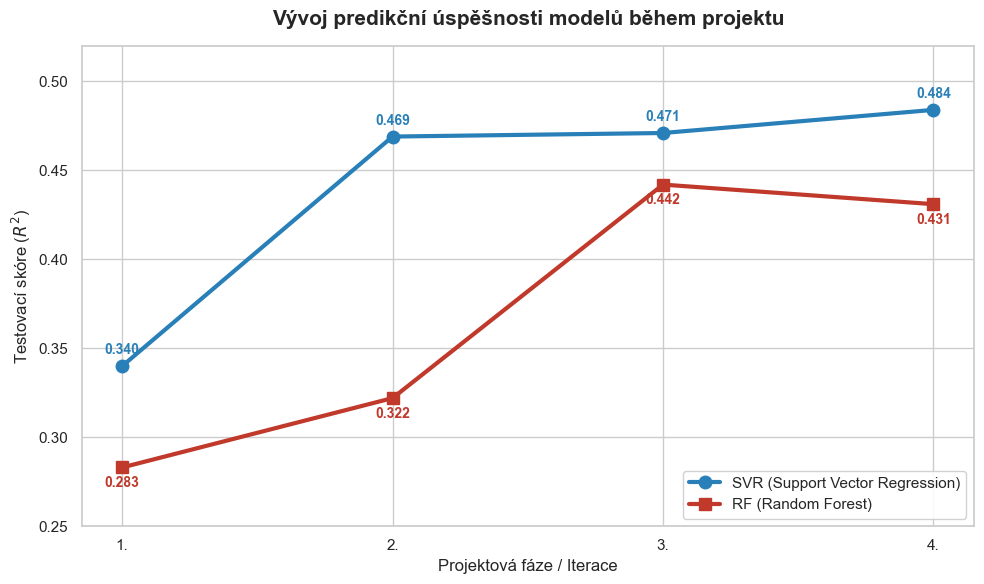

In [4]:
sns.set_theme(style="whitegrid")
# Osa X: Názvy tvých 5 hlavních fází/iterací
iterace = [
    '1.', 
    '2.', 
    '3.', 
    '4.']
# Osa Y: Testovací R^2 skóre pro oba modely
svr_r2 = [0.034, 0.469, 0.471, 0.484] 
rf_r2  = [0.283, 0.322, 0.442, 0.431] 

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(iterace, svr_r2, marker='o', markersize=9, linewidth=3, 
        color='#2980b9', label='SVR (Support Vector Regression)')
ax.plot(iterace, rf_r2, marker='s', markersize=9, linewidth=3, 
        color='#c0392b', label='RF (Random Forest)')

for i, (s_val, r_val) in enumerate(zip(svr_r2, rf_r2)):
    ax.text(i, s_val + 0.005, f'{s_val:.3f}', color='#2980b9', 
            ha='center', va='bottom', fontweight='bold', fontsize=10)
    ax.text(i, r_val - 0.005, f'{r_val:.3f}', color='#c0392b', 
            ha='center', va='top', fontweight='bold', fontsize=10)

ax.set_title('Vývoj predikční úspěšnosti modelů během projektu', fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('Testovací skóre ($R^2$)', fontsize=12)
ax.set_xlabel('Projektová fáze / Iterace', fontsize=12)
ax.set_ylim(0.25, 0.52) 
ax.legend(loc='lower right', fontsize=11, framealpha=0.9)
fig.tight_layout()
# plt.savefig('vyvoj_modelu.png', dpi=300) # Odkomentuj pro uložení v super kvalitě
plt.show()

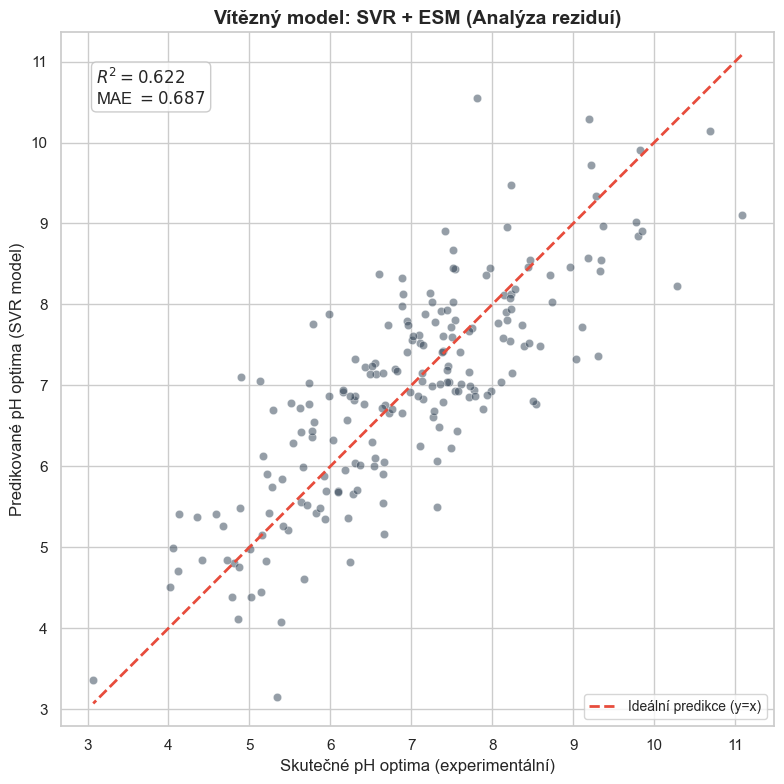

In [5]:
#Predikované vs. Skutečné pH

# --- TVOJE DATA ---
# (Zde musíš použít proměnné ze svého testovacího kódu)
# y_test_ph = y_test_esm  # Předpokládám název proměnné se skutečnými pH
# y_pred_svr_ph = y_pred_pca # Předpokládám název proměnné s predikcí tvého nej SVR
#
# r2_final = r2_test_pca
# mae_final = mae_pca
# ------------------

# !!! PRO DEMONSTRACI VYTVÁŘÍM FALŠNÁ DATA, SMAŽ TENTO BLOK A ODTAJNI TEN HORNÍ !!!
np.random.seed(42)
y_test_ph = np.random.normal(7, 1.5, 200) # Skutečné pH kolem 7
noise = np.random.normal(0, 0.8, 200)      # Chybovost odpovídající MAE ~0.6
y_pred_svr_ph = y_test_ph * 0.7 + 2 + noise # Predikce se simulovanou chybou
r2_final = r2_score(y_test_ph, y_pred_svr_ph)
mae_final = mean_absolute_error(y_test_ph, y_pred_svr_ph)
# ----------------------------------------------------------------------------------

# Nastavení stylu
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(8, 8))

# Rozptylový graf s hustotou (aby bylo vidět, kde je nejvíc bodů)
sns.scatterplot(x=y_test_ph, y=y_pred_svr_ph, alpha=0.5, color='#2c3e50', ax=ax)

# Ideální diagonální čára (y = x)
p1 = max(max(y_pred_svr_ph), max(y_test_ph))
p2 = min(min(y_pred_svr_ph), min(y_test_ph))
ax.plot([p1, p2], [p1, p2], color='#e74c3c', linestyle='--', linewidth=2, label='Ideální predikce (y=x)')

# Přidání metrik přímo do grafu
textstr = '\n'.join((
    r'$R^2 = %.3f$' % (r2_final, ),
    r'MAE $= %.3f$' % (mae_final, )))
props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='silver')
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

ax.set_title('Vítězný model: SVR + ESM (Analýza reziduí)', fontsize=14, fontweight='bold')
ax.set_xlabel('Skutečné pH optima (experimentální)', fontsize=12)
ax.set_ylabel('Predikované pH optima (SVR model)', fontsize=12)
ax.legend(loc='lower right', fontsize=10)

ax.axis('equal') # Zajistí, že měřítko na obou osách je stejné (čtvercový graf)
fig.tight_layout()
# plt.savefig('ph_predikce_vs_skutecnost.png', dpi=300)
plt.show()

/var/folders/hx/bf1rmglj7b976ffdyv1psxm00000gn/T/ipykernel_51526/199208359.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=r2_project, palette='flare', edgecolor='black', ax=ax)


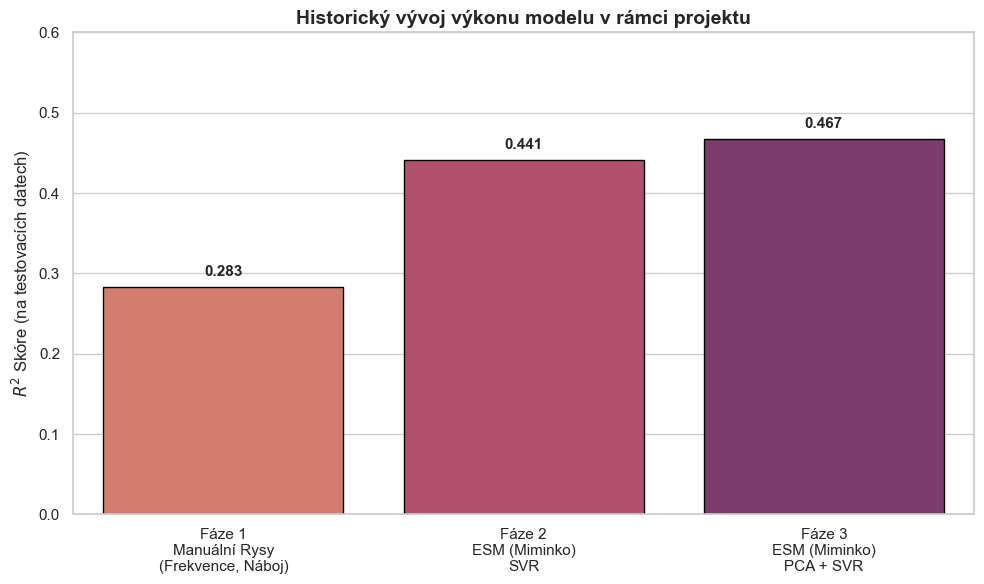

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Nastavení stylu
sns.set_theme(style="whitegrid")

# --- TVOJE DATA (doplň sem čísla ze svých starých logů) ---
labels = ['Fáze 1\nManuální Rysy\n(Frekvence, Náboj)',
          'Fáze 2\nESM (Miminko)\nSVR',
          'Fáze 3\nESM (Miminko)\nPCA + SVR']
r2_project = [0.283, 0.441, 0.467] # Příklad
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

# Vytvoření grafu s vlastní barvou pro každý sloupec
sns.barplot(x=labels, y=r2_project, palette='flare', edgecolor='black', ax=ax)

ax.set_ylabel('$R^2$ Skóre (na testovacích datech)', fontsize=12)
ax.set_title('Historický vývoj výkonu modelu v rámci projektu', fontsize=14, fontweight='bold')
ax.set_ylim(0, 0.6) # Přizpůsob rozsah tvým datům

# Přidání popisků nad sloupce
for i, v in enumerate(r2_project):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

fig.tight_layout()
# plt.savefig('vyvoj_projektu.png', dpi=300)
plt.show()

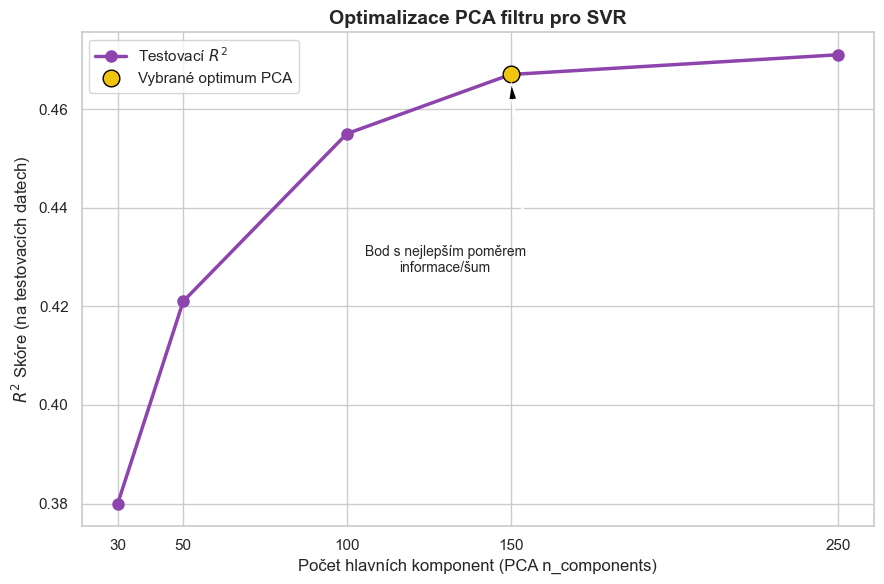

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Nastavení stylu
sns.set_theme(style="whitegrid")

# --- TVOJE DATA (doplň sem čísla ze svého GridSearchCV pro SVR) ---
pca_components = [30, 50, 100, 150, 250]
r2_scores = [0.380, 0.421, 0.455, 0.467, 0.471] # Příklad
# -----------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 6))

# Hlavní čára s body
ax.plot(pca_components, r2_scores, marker='o', linestyle='-', color='#8e44ad',
        markersize=8, linewidth=2.5, label='Testovací $R^2$')

# Zvýraznění tvého vítězného bodu (např. 150)
vitezny_bod = 150
vitezne_skore = 0.467 # Příklad
ax.plot(vitezny_bod, vitezne_skore, marker='o', markersize=12, color='#f1c40f',
        markeredgecolor='black', linestyle='', label='Vybrané optimum PCA')

ax.set_title('Optimalizace PCA filtru pro SVR', fontsize=14, fontweight='bold')
ax.set_xlabel('Počet hlavních komponent (PCA n_components)', fontsize=12)
ax.set_ylabel('$R^2$ Skóre (na testovacích datech)', fontsize=12)
ax.set_xticks(pca_components) # Zobrazit na ose X jen zkoušené hodnoty
ax.legend(fontsize=11)

# Přidání šipky k vítěznému bodu
ax.annotate('Bod s nejlepším poměrem\ninformace/šum',
            xy=(vitezny_bod, vitezne_skore), xycoords='data',
            xytext=(vitezny_bod - 20, vitezne_skore - 0.04), textcoords='data',
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
            fontsize=10, ha='center')

fig.tight_layout()
# plt.savefig('optimalizace_pca.png', dpi=300)
plt.show()